<a href="https://colab.research.google.com/github/JustTheCoolest/DataQuestContest/blob/main/EDA_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

In [ ]:
!pip install kaggle

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/DataQuest/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json  # Secure the file

In [ ]:
!kaggle datasets download -d puneet6060/intel-image-classification


Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
 96% 333M/346M [00:06<00:00, 58.9MB/s]
100% 346M/346M [00:06<00:00, 56.3MB/s]


In [ ]:
!unzip -q intel-image-classification.zip -d ./intel-image-classification


In [ ]:
dataset_path = "./intel-image-classification/seg_train/seg_train"


In [4]:
import os
import numpy as np
import pandas as pd
from PIL import Image

# Set the dataset path
dataset_path = "/content/drive/MyDrive/Dataquest -Data/output"

# Validate dataset path
if not os.path.exists(dataset_path):
    raise ValueError(f"❌ Dataset path not found: {dataset_path}")

# Get all categories (folders)
categories = sorted([cat for cat in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, cat))])
num_categories = len(categories)

image_count = 0
corrupt_count = 0
dimensions = []
category_distribution = {}

for category in categories:
    category_path = os.path.join(dataset_path, category)

    if os.path.isdir(category_path):
        images = [img for img in os.listdir(category_path) if img.lower().endswith(('png', 'jpg', 'jpeg'))]
        category_distribution[category] = len(images)
        image_count += len(images)

        for img_file in images:
            img_path = os.path.join(category_path, img_file)
            try:
                with Image.open(img_path) as img:
                    dimensions.append(img.size)  # (width, height)
            except:
                corrupt_count += 1  # Count corrupt images

# Compute statistics for image dimensions
if dimensions:
    widths, heights = zip(*dimensions)
    avg_width, avg_height = np.mean(widths), np.mean(heights)
    min_width, max_width = min(widths), max(widths)
    min_height, max_height = min(heights), max(heights)
else:
    avg_width = avg_height = min_width = max_width = min_height = max_height = 0

# Summary Output
summary = {
    "Total Images (Including Corrupt)": image_count + corrupt_count,
    "Valid Images": image_count,
    "Corrupt Images": corrupt_count,
    "Total Categories": num_categories,
    "Avg Image Dimensions": (round(avg_width, 2), round(avg_height, 2)),
    "Image Dimension Range": {"Width": (min_width, max_width), "Height": (min_height, max_height)},
    "Category Distribution (%)": {cat: round((count / max(image_count, 1)) * 100, 2) for cat, count in category_distribution.items()}
}

# Convert to DataFrame for better readability
df_summary = pd.DataFrame.from_dict(summary, orient='index')
print(df_summary)

                                                                                  0
Total Images (Including Corrupt)                                               5497
Valid Images                                                                   5497
Corrupt Images                                                                    0
Total Categories                                                                 30
Avg Image Dimensions                                               (643.76, 508.31)
Image Dimension Range                   {'Width': (99, 5760), 'Height': (90, 7304)}
Category Distribution (%)         {'1': 1.75, '10': 5.58, '11': 1.73, '12': 3.13...


In [5]:
import cv2

corrupt_images = []
valid_images = 0

for category in categories:
    category_path = os.path.join(dataset_path, category)
    if os.path.isdir(category_path):
        for img_file in os.listdir(category_path):
            img_path = os.path.join(category_path, img_file)
            try:
                img = cv2.imread(img_path)
                if img is None:
                    corrupt_images.append(img_path)
                else:
                    valid_images += 1
            except:
                corrupt_images.append(img_path)

# Print Summary
print(f"✅ Valid Images: {valid_images}")
print(f"❌ Corrupt or Unreadable Images: {len(corrupt_images)}")

# Show first 5 corrupt image paths (if any)
if corrupt_images:
    print("\n🔍 First 5 Corrupt Images:")
    for img in corrupt_images[:5]:
        print(img)

✅ Valid Images: 5497
❌ Corrupt or Unreadable Images: 0


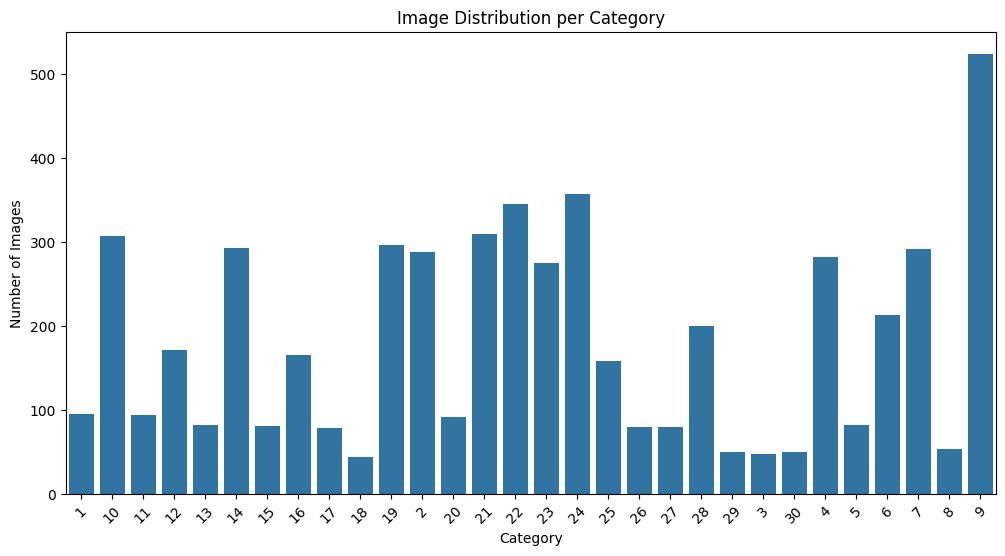

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=list(category_distribution.keys()), y=list(category_distribution.values()))
plt.xticks(rotation=45)
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.title('Image Distribution per Category')
plt.show()


In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Set the dataset path
dataset_path = '/content/drive/MyDrive/Dataquest -Data/output'

# Define valid image extensions
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

# Collect all subdirectories under the dataset_path
categories = [os.path.join(dataset_path, d) for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

# Plot images for each category (subfolder)
fig, axes = plt.subplots(len(categories), 5, figsize=(15, len(categories) * 3))

for i, category_path in enumerate(categories):
    # Get valid image files within the subdirectory
    image_files = [f for f in os.listdir(category_path)
                   if os.path.isfile(os.path.join(category_path, f)) and f.lower().endswith(valid_extensions)]

    if len(image_files) == 0:
        print(f"No valid images found in {category_path}. Skipping this category.")
        continue  # Skip if no valid images are found

    # Ensure the folder has enough images for sampling
    try:
        sample_images = random.sample(image_files, min(5, len(image_files)))  # Sample up to 5 images
    except ValueError as e:
        print(f"Error with category '{category_path}': {e}")
        continue

    for j, img_file in enumerate(sample_images):
        img_path = os.path.join(category_path, img_file)

        # Open and display the image
        try:
            img = Image.open(img_path)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
        except Exception as e:
            print(f"Could not open image {img_path}: {e}")
            axes[i, j].axis('off')  # Leave the axis blank if an image can't be opened

# Adjust layout
plt.tight_layout()
plt.show()


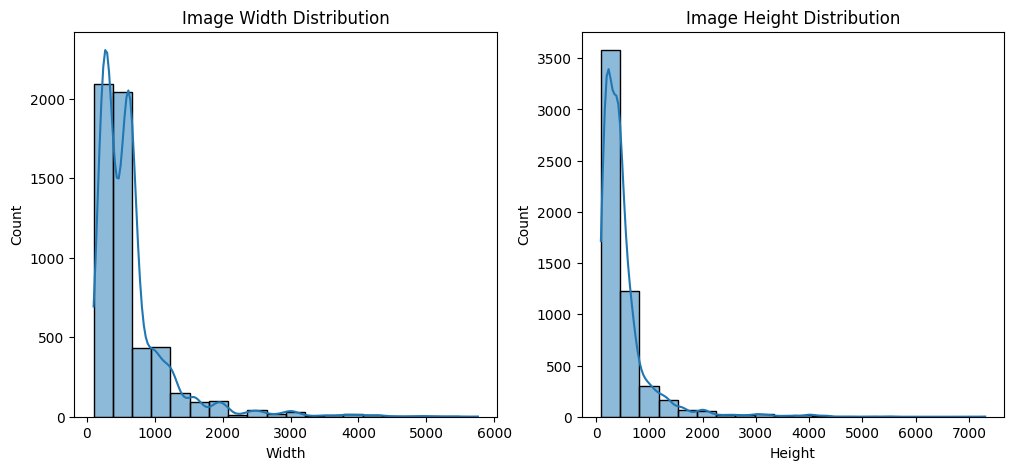

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(widths, bins=20, kde=True)
plt.xlabel('Width')
plt.title('Image Width Distribution')

plt.subplot(1, 2, 2)
sns.histplot(heights, bins=20, kde=True)
plt.xlabel('Height')
plt.title('Image Height Distribution')

plt.show()


In [18]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

target_size = (128, 128)  # Standardizing resolution

datagen = ImageDataGenerator(
    rescale=1./255,  # Normalization
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=target_size,
    batch_size=32,
    class_mode='categorical'
)

print("✅ Data Augmentation & Preprocessing Done!")


Found 5497 images belonging to 30 classes.
✅ Data Augmentation & Preprocessing Done!


In [ ]:
!pip install torch torchvision albumentations opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlink

In [19]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
dataset_path = "/content/drive/MyDrive/Dataquest -Data/output"


# Define Image Transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),   # Resize images
    transforms.ToTensor(),           # Convert to tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize
])

# Load Dataset
dataset = ImageFolder(root=dataset_path, transform=transform)
num_classes = len(dataset.classes)  # Automatically get number of classes

# Split into Training (80%) & Validation (20%)
train_size = int(0.7 * len(dataset))
val_size = len(dataset) - train_size
dataset, val_dataset = random_split(dataset, [train_size, val_size])

# DataLoader
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"✅ Data Loaded: {len(dataset)} images, {num_classes} classes")


✅ Data Loaded: 3847 images, 30 classes


In [21]:
import torch.nn as nn
import torchvision.models as models

# Load Pretrained ResNet-18
model = models.resnet18(pretrained=True)

# Modify the last layer to match the number of categories
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, num_classes)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"✅ Model Loaded on {device} | Output Classes: {num_classes}")


✅ Model Loaded on cpu | Output Classes: 30


In [22]:
import torch.optim as optim

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Function
def train_model(model, train_loader, val_loader, epochs=5):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        val_acc = evaluate_model(model, val_loader)
        print(f"Epoch {epoch+1}: Loss={running_loss:.4f}, Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")

    print("✅ Training Completed!")

# Evaluation Function
def evaluate_model(model, val_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total  # Return accuracy %

# Train for 5 epochs
train_model(model, train_loader, val_loader, epochs=3)


Epoch 1: Loss=133.5110, Train Acc=69.33%, Val Acc=70.91%
Epoch 2: Loss=49.4526, Train Acc=87.57%, Val Acc=80.48%
Epoch 3: Loss=37.1401, Train Acc=91.01%, Val Acc=85.15%
✅ Training Completed!


In [23]:
# Define path to save the model
model_save_path = "/content/drive/MyDrive/DataQuest/resnet18_trained.pth"

# Save model state_dict
torch.save(model.state_dict(), model_save_path)

print(f"✅ Model saved at {model_save_path}")


✅ Model saved at /content/drive/MyDrive/DataQuest/resnet18_trained.pth


In [25]:
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import os

# Load the trained model
# model = torch.load("/content/drive/MyDrive/DataQuest/resnet18_trained.pth", map_location=torch.device('cpu'))  # Change filename accordingly
# model.eval()

model = models.resnet18(pretrained=False)  # Set False since we are loading trained weights
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, num_classes)  # Ensure the same number of classes

# Load saved weights
model.load_state_dict(torch.load(model_save_path))

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()  # Set to evaluation mode

print("✅ Model successfully loaded & ready for inference!")

# # Define image transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Function to make predictions
def predict_image(image_path, model):
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0)  # Add batch dimension
    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)
    return predicted.item()

# Directory containing new images
image_folder = "/content/drive/MyDrive/Dataquest -Data/Combined"  # Change this to the actual path
image_files = [f for f in os.listdir(image_folder) if f.endswith(('png', 'jpg', 'jpeg'))]




/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
<ipython-input-25-e70ef5c6f7d3>:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recomme

✅ Model successfully loaded & ready for inference!


In [26]:
import pandas as pd

# Create an empty list to store the results
results = []

# Make predictions and store results in the list
for img_file in image_files:
    img_path = os.path.join(image_folder, img_file)
    try:
        prediction = predict_image(img_path, model)
        results.append({'Img_name': img_file, 'Class_name': prediction})
    except Exception as e:
        print(f"Error processing {img_file}: {e}")
        results.append({'Img_name': img_file, 'Class_name': 'Error'}) # Append with 'Error' if prediction fails

# Create a pandas DataFrame from the results
df = pd.DataFrame(results)

# Print or save the DataFrame
df
# df.to_csv("image_predictions.csv", index=False) # Optional: save to a CSV file


,Img_name,Class_name
0,img746.jpg,23
1,img764.jpg,26
2,img757.jpg,29
3,img796.jpg,11
4,img783.jpg,24
...,...,...
1731,img827.jpg,11
1732,img766.jpg,10
1733,img777.jpg,21
1734,img779.jpg,29


In [ ]:
# # Make predictions
# for img_file in image_files:
#     img_path = os.path.join(image_folder, img_file)
#     prediction = predict_image(img_path, model)
#     print(f"Image: {img_file}, Predicted Class: {prediction}")

In [27]:
df.to_csv('Pipeline.csv', index=False)